# SwiGLU Curve

The equation for SwiGLU is:

$$
\operatorname{SwiGLU}(x,g)
=
\operatorname{SiLU}(x)\,g
=
x\sigma(x)\,g
$$

It normally combines two inputs and utilizes a gating mechanism (it is not normally a one-input activation curve), so it is usually not drawn in a plot with one input, such as Sigmoid or ReLU are normally.

For what we are doing below (single input version), where x = g, it would be:

$$
\operatorname{SwiGLU}(x,x)
=
\operatorname{SiLU}(x)\,x
=
x^2\sigma(x)
=
\frac{x^2}{1+e^{-x}}
$$

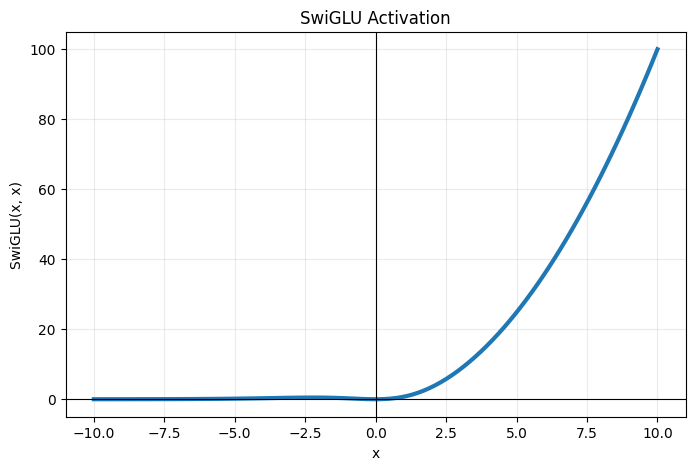

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def silu(x):
    return x * sigmoid(x)


def swiglu(x, gate=None):
    """
    SwiGLU(x, gate) = SiLU(x) * gate

    If no separate gate is supplied, gate = x so that
    the two-input operation can be visualized as one curve
    """
    if gate is None:
        gate = x

    return silu(x) * gate


# values from -10 to 10
x = np.linspace(-10, 10, 100)
y = swiglu(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=3)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("x")
plt.ylabel("SwiGLU(x, x)")
plt.title("SwiGLU Activation")
plt.grid(alpha=0.25)
plt.show()